In [276]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
from sklearn.preprocessing import StandardScaler
from src.utils.cox_models import *
scipy.integrate.simps = scipy.integrate.simpson
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from sksurv.util import Surv
from itertools import product
import torch

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
pp = Preprocessor()

In [3]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)
Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [4]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")
df_merged = TorchPreprocessing(clean_mRNA_df,df_clinical_data, 2000).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818
Genes before Treshold: 2003
count    2003.000000
mean       76.306041
std       158.918820
min         0.000000
25%         0.000000
50%         0.000000
75%        20.000000
max       519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1805


array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [6]:
zero_reduced_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer")
print(f"Samples: {zero_reduced_df.shape[0]}, Genes: {zero_reduced_df.shape[1]}")
zero_reduced_df =  zero_reduced_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

Genes before Treshold: 1805
count    1805.000000
mean       30.929640
std        84.082264
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max       415.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1805
Samples: 519, Genes: 1806


In [198]:
results_df

,HER2-enriched,Luminal A,Luminal B,TNBC,AveExpr,F,pvalue,adj_pvalue
YTHDF1,10.879097,10.704586,10.782180,10.716942,10.726453,69262.336815,0.000000e+00,0.000000e+00
CCR7,6.044679,5.968886,6.192913,6.938782,6.166055,1634.501163,0.000000e+00,0.000000e+00
FBXO48,5.023124,4.763917,4.780206,4.962661,4.810496,6907.552264,0.000000e+00,0.000000e+00
PTPRN2,6.436115,7.635121,7.006290,5.565086,7.144821,1749.138908,0.000000e+00,0.000000e+00
TRIOBP,10.290598,10.180434,10.190821,10.256202,10.199346,42629.167766,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...
SSX4,0.762482,0.202256,0.332518,0.421870,0.283380,15.974664,4.389646e-13,4.399411e-13
RPTN,0.281796,0.270517,0.264407,0.518887,0.310740,15.355910,1.456288e-12,1.458717e-12
REXO1L1P,0.128429,0.201275,0.248773,0.140834,0.195561,15.321054,1.557997e-12,1.559728e-12
CSN1S1,0.152372,0.442308,0.377112,0.388976,0.410550,14.655928,5.644621e-12,5.647756e-12


In [342]:
N_GENES = 100
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES]
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data, N_GENES)
Torch_preprocessing.genes_expression = top_genes_limma

In [343]:
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data, N_GENES)
Torch_preprocessing.genes_expression = top_genes_limma
X_scaled, durations, events, scaler = Torch_preprocessing.get_data_set(time_months=60)

Genes before Treshold: 103
count    103.000000
mean       1.368932
std        3.845013
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       22.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 103


In [344]:
X_scaled.shape

(519, 100)

In [345]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)

In [346]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

In [347]:
train_X.shape

torch.Size([415, 100])

Grid Search for the best Model

In [303]:
from itertools import product

param_grid = {
    "num_nodes": [[32,16], [32,32], [64,32]],
    "dropout": [0.0, 0.2, 0.4],
    "batch_norm": [True, False],
    "lr": [1e-3, 5e-4, 1e-4],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size": [128, 256],
}

grid = list(product(
    param_grid["num_nodes"],
    param_grid["dropout"],
    param_grid["batch_norm"],
    param_grid["lr"],
    param_grid["weight_decay"],
    param_grid["batch_size"],
))

In [304]:
in_features = train_X.shape[1]
output_bias = False

best_score = -1
best_params = None

train_X = np.array(train_X)
train_durations = np.array(train_durations)
train_events = np.array(train_events).astype(bool)

val_X = np.array(val_X)
val_durations = np.array(val_durations)
val_events = np.array(val_events).astype(bool)

for num_nodes,dp,bn, lr, wd, batch_size  in grid:
    net = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=num_nodes,
        out_features=1,
        dropout=dp,
        output_bias=output_bias,
        batch_norm=bn,
        )
    
    model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=wd),)
    
    model.optimizer.set_lr(lr)
    model.fit(
                input=train_X,
                target=(train_durations, train_events),
                epochs=100,
                verbose=False,
                val_data=(val_X, (val_durations, val_events)),
                val_batch_size=batch_size
            )
    
    model.net.eval()
    model.compute_baseline_hazards()
    surv = model.predict_surv_df(val_X)

    ev = EvalSurv(surv, val_durations, val_events)
    c_index = ev.concordance_td()
    if c_index > best_score:
                best_score = c_index
                best_params = (num_nodes, dp, bn, lr, wd, batch_size)

    

print(best_params, best_score)


([32, 32], 0.4, True, 0.0005, 0, 256) 0.9649122807017544


Training the Model

In [348]:
num_nodes = [32, 32]
out_features = 1
dropout = 0.4
batch_norm = True
lr = 0.005
weight_decay = 0
batch_size = 256



net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, 
    num_nodes=num_nodes, 
    out_features=out_features, 
    batch_norm=batch_norm,
    dropout=dropout,
    output_bias=output_bias
)
model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=weight_decay))


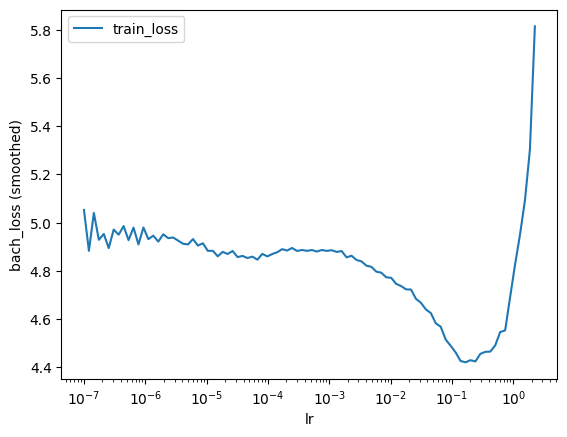

In [349]:
batch_size = batch_size
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=20)

_ = lrfinder.plot()

In [350]:
train_durations.shape

torch.Size([415])

In [351]:
model.optimizer.set_lr(lr)


In [352]:
epochs = 100
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=10)]
verbose = True

In [353]:
%%time
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.8700,	val_loss: 3.2453
1:	[0s / 0s],		train_loss: 4.8765,	val_loss: 3.1754
2:	[0s / 0s],		train_loss: 4.5932,	val_loss: 3.1031
3:	[0s / 0s],		train_loss: 4.4289,	val_loss: 3.0364
4:	[0s / 0s],		train_loss: 4.3208,	val_loss: 2.9832
5:	[0s / 0s],		train_loss: 4.1967,	val_loss: 2.9359
6:	[0s / 0s],		train_loss: 4.2202,	val_loss: 2.8903
7:	[0s / 0s],		train_loss: 4.3082,	val_loss: 2.8544
8:	[0s / 0s],		train_loss: 4.0703,	val_loss: 2.8315
9:	[0s / 0s],		train_loss: 4.0758,	val_loss: 2.8161
10:	[0s / 0s],		train_loss: 3.9694,	val_loss: 2.8055
11:	[0s / 0s],		train_loss: 4.0354,	val_loss: 2.7989
12:	[0s / 0s],		train_loss: 3.6776,	val_loss: 2.7985
13:	[0s / 0s],		train_loss: 3.6590,	val_loss: 2.7888
14:	[0s / 0s],		train_loss: 3.8445,	val_loss: 2.7938
15:	[0s / 0s],		train_loss: 3.5316,	val_loss: 2.7897
16:	[0s / 0s],		train_loss: 3.7114,	val_loss: 2.7707
17:	[0s / 0s],		train_loss: 3.1450,	val_loss: 2.7225
18:	[0s / 0s],		train_loss: 3.1711,	val_loss: 2.6588
19:

torch.Size([52, 100])

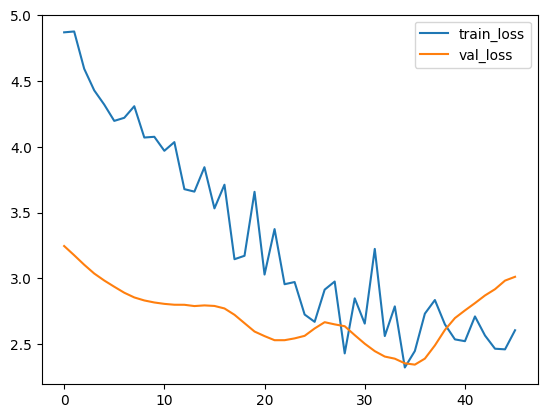

In [354]:
_ = log.plot()
val_X.shape

Log Likehood (The Loss)

In [355]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()


-2.3435154

In [356]:
_ = model.compute_baseline_hazards()

In [357]:
surv = model.predict_surv_df(input=test_X)

In [358]:
chf = model.predict_cumulative_hazards(test_X)
chf.shape
#275 → número de puntos de tiempo
#52 -> pacientes 

(275, 52)

Kaplan Meier

In [359]:
risk_nn = model.net(test_X).flatten()

list_risk = []
for i in risk_nn:
    list_risk.append(i.item())



For this group the risk High

For the time 0 the risk group is 26
For the time 12 the risk group is 19
For the time 24 the risk group is 12
For the time 36 the risk group is 9
For the time 48 the risk group is 5
For the time 60 the risk group is 0
For the time 72 the risk group is 0
For the time 84 the risk group is 0
For the time 96 the risk group is 0
For the time 108 the risk group is 0
For the time 120 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 26
For the time 12 the risk group is 22
For the time 24 the risk group is 13
For the time 36 the risk group is 6
For the time 48 the risk group is 4
For the time 60 the risk group is 0
For the time 72 the risk group is 0
For the time 84 the risk group is 0
For the time 96 the risk group is 0
For the time 108 the risk group is 0
For the time 120 the risk group is 0


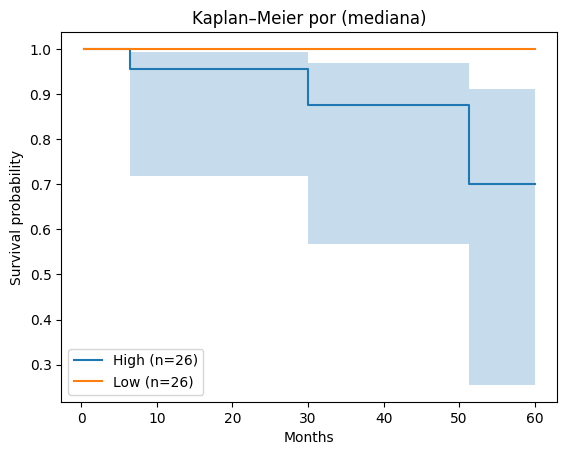

In [360]:
df = pd.DataFrame()

thr = np.median(list_risk)
df["group"] = np.where(risk_nn > thr, "High", "Low")
df["duration"] = test_durations
df["event"] = test_events

for g in ["High", "Low"]:
        sub = df[df["group"] == g]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub["duration"].to_numpy(dtype=float)
            
        time_points_months = np.array([0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120])
        at_risk = [(time > tp).sum() for tp in time_points_months]
        print(f"\nFor this group the risk {g}\n")
        x = [(time, risk) for time,risk in zip(time_points_months, at_risk)]
        for i, _ in enumerate(x):
            print(f"For the time {x[i][0]} the risk group is {x[i][1]}")
                
        event_60_month = event.copy()
        event_60_month[time > 120] = False
        time_60_months = np.minimum(time, 120)
        time, prob_survival, conf_int = kaplan_meier_estimator(event_60_month, time_60_months, conf_type="log-log")  # type: ignore # event True=evento, False=censura
        plt.step(time, prob_survival, where="post", label=f"{g} (n={len(sub)})")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.title(f"Kaplan–Meier por (mediana)")
plt.legend()
plt.show()

Log Rank of the Model

In [361]:

time_all = df["duration"].to_numpy(dtype=float)
event_all = df["event"].to_numpy(dtype=bool)
event_60_months = event_all.copy()
event_60_months[time_all > 60] = False
time_60_months = np.minimum(time_all, 60)

y = Surv.from_arrays(event_60_months, time_60_months)
chisq, pvalue = compare_survival(y, df["group"].to_numpy())
print(f"Log-rank: chi2={chisq:.3f}, p={pvalue:.4g}")


Log-rank: chi2=2.311, p=0.1285


Prediction of survival of the Patients

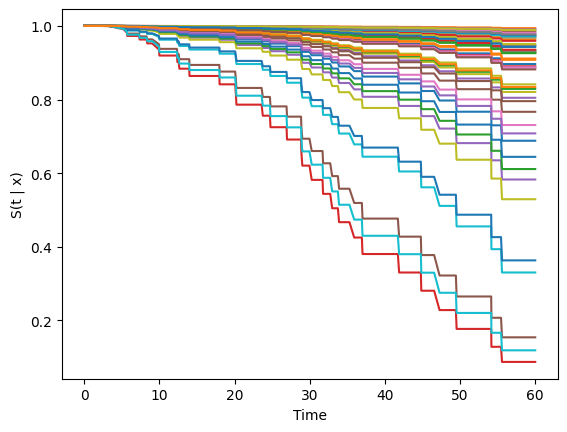

In [376]:
surv.iloc[:, :].plot()
plt.ylabel('S(t | x)')
plt.legend().set_visible(False)
_ = plt.xlabel("Time")

In [363]:
test_durations = test_durations.cpu().detach().numpy()
test_events = test_events.cpu().detach().numpy()

In [364]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


Concordance of the Model

In [365]:
print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.9583333333333334


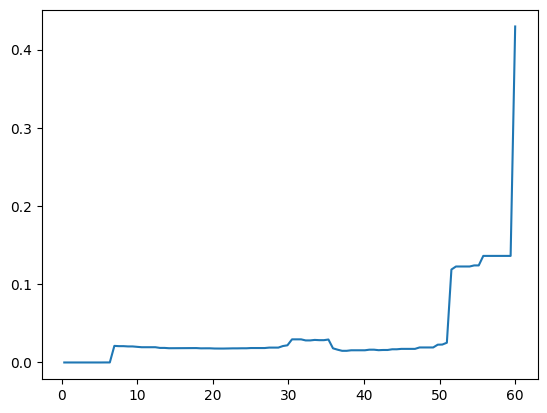

In [366]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [367]:
ev.integrated_brier_score(time_grid=time_grid)

0.03506793943158555

In [368]:
ev.integrated_nbll(time_grid)

0.1295592236660898